# Câu 2: Employee Attrition Prediction

# 1. DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
df = pd.concat([train_df,test_df], ignore_index=True)

In [4]:
df.head(10)

,Employee ID,Age,Gender,Months at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,No,No,No,Fair,Medium,Stayed
5,24368,38,Female,3,Technology,9977,Fair,High,Below Average,3,No,37,Bachelor’s Degree,Married,0,Mid,Medium,No,No,Yes,Fair,High,Left
6,64970,47,Male,23,Education,3681,Fair,High,High,1,Yes,75,High School,Divorced,3,Entry,Small,No,No,No,Good,Medium,Left
7,36999,48,Male,16,Finance,11223,Excellent,Very High,High,2,No,5,Master’s Degree,Married,4,Entry,Medium,No,No,No,Excellent,Low,Stayed
8,32714,57,Male,44,Education,3773,Good,Medium,High,1,Yes,39,High School,Married,4,Entry,Medium,No,No,No,Fair,Medium,Stayed
9,15944,24,Female,1,Healthcare,7319,Poor,High,Average,1,Yes,57,PhD,Single,4,Entry,Large,No,No,Yes,Good,Low,Left


In [5]:
df.sort_values(by='Employee ID', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)
# lets check again
df.head()

,Employee ID,Age,Gender,Months at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,1,56,Male,41,Education,5209,Fair,Very High,Average,0,No,98,Associate Degree,Married,0,Entry,Small,No,No,No,Good,Low,Stayed
1,2,46,Female,22,Technology,9099,Fair,Medium,Average,0,No,13,Bachelor’s Degree,Married,0,Entry,Medium,No,No,No,Good,High,Left
2,3,32,Male,16,Education,4239,Good,High,Below Average,0,No,54,High School,Single,0,Mid,Small,No,No,No,Poor,Low,Stayed
3,4,25,Female,17,Finance,6834,Fair,High,Average,0,Yes,62,PhD,Single,2,Entry,Medium,No,No,No,Poor,High,Left
4,5,38,Female,2,Finance,12176,Fair,Very High,Below Average,0,No,75,Bachelor’s Degree,Married,5,Entry,Small,No,No,No,Good,Medium,Left


In [6]:
df.describe()

,Employee ID,Age,Months at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents
count,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000
mean,37249.500000,38.529746,15.721603,7299.379514,0.832935,49.991584,1.650326
std,21505.864514,12.083456,11.223744,2152.508566,0.995289,28.513611,1.553633
min,1.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000
25%,18625.250000,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000
50%,37249.500000,39.000000,13.000000,7348.000000,1.000000,50.000000,1.000000
75%,55873.750000,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000


***** Remark *****

- Tập dữ liệu Train gồm 59,598 dòng và Test gồm 14,900 dòng với 23 cột thuộc tính sạch hoàn toàn (0% giá trị khuyết thiếu, 0 bản ghi trùng lặp)
- Biến mục tiêu Attrition có tỷ lệ phân phối lý tưởng (52.45% Ở lại và 47.55% Nghỉ việc), tạo điều kiện tối ưu để xây dựng mô hình phân loại nhị phân cân bằng mà không cần áp dụng các kỹ thuật lấy mẫu lại (Resampling)

# 2. EDA

In [7]:
# Checking Missing value

print("\n--- Bảng tổng hợp Missing Values ---")
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_summary)


--- Bảng tổng hợp Missing Values ---
                          Missing Values  Percentage (%)
Employee ID                            0             0.0
Age                                    0             0.0
Gender                                 0             0.0
Months at Company                      0             0.0
Job Role                               0             0.0
Monthly Income                         0             0.0
Work-Life Balance                      0             0.0
Job Satisfaction                       0             0.0
Performance Rating                     0             0.0
Number of Promotions                   0             0.0
Overtime                               0             0.0
Distance from Home                     0             0.0
Education Level                        0             0.0
Marital Status                         0             0.0
Number of Dependents                   0             0.0
Job Level                              0          

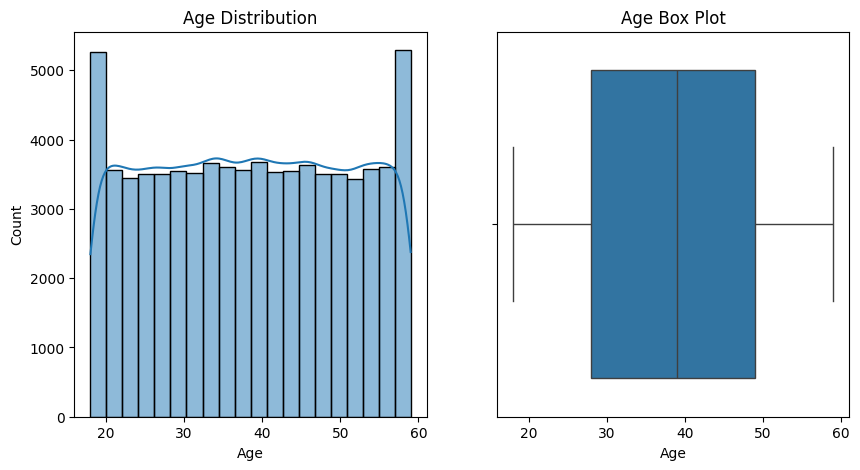

In [8]:
# Age Distribution

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'])
plt.title('Age Box Plot')
plt.show()

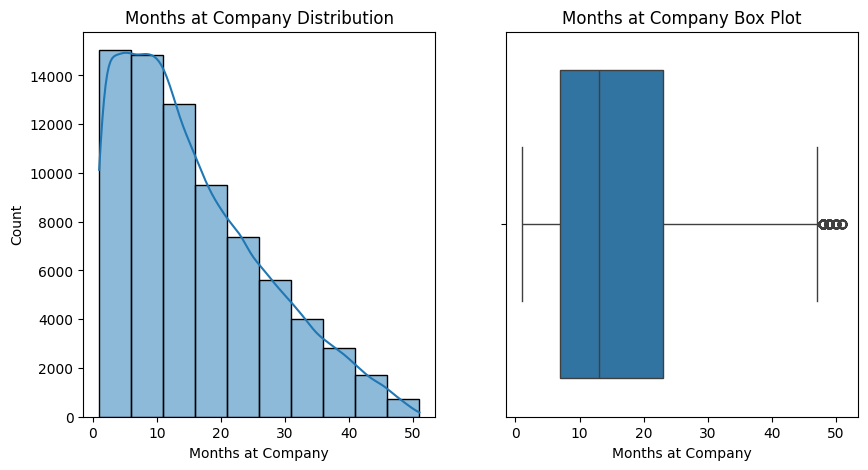

In [9]:
# Tenure at Company

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Months at Company'], kde=True, bins=10)
plt.title('Months at Company Distribution')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Months at Company'])
plt.title('Months at Company Box Plot')
plt.show()

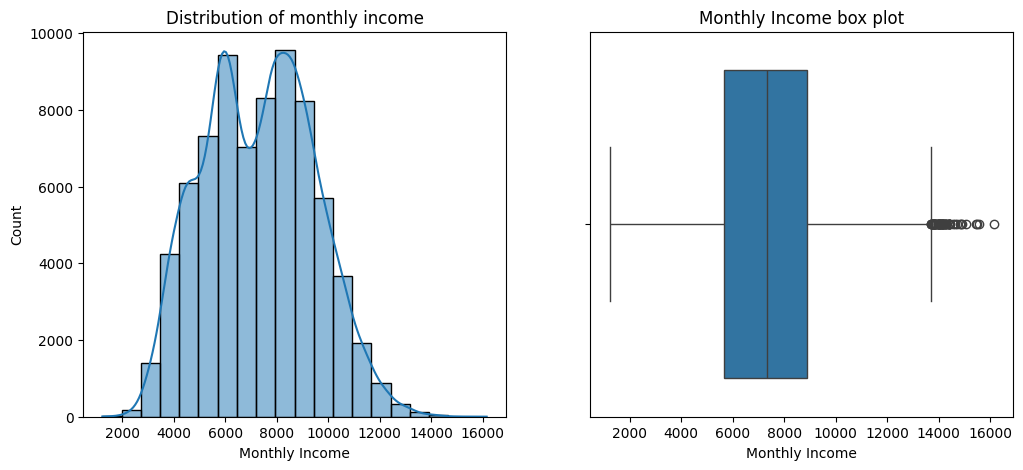

In [10]:
# Monthly income at Company

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Monthly Income'], kde=True, bins=20)
plt.title('Distribution of monthly income')
plt.subplot(1,2,2)
sns.boxplot(x = df['Monthly Income'])
plt.title('Monthly Income box plot')
plt.show()

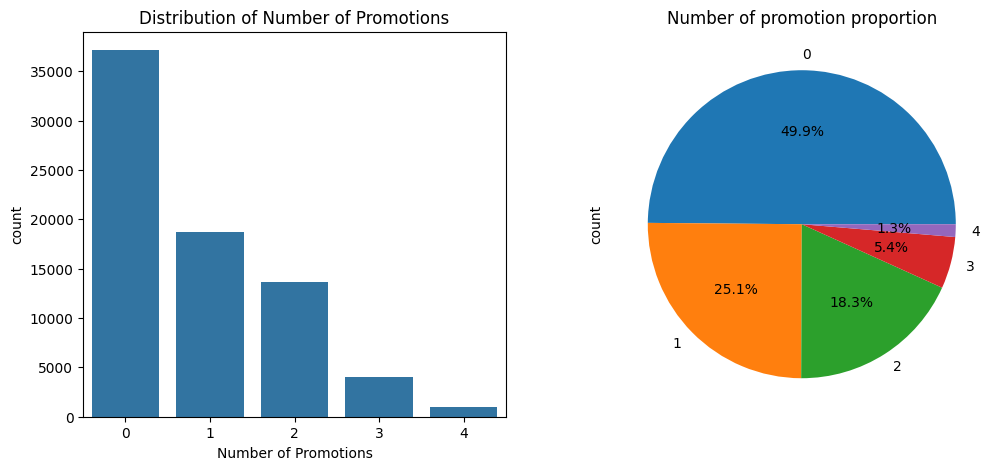

In [11]:
# Number of Promotions

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x=df['Number of Promotions'])
plt.title('Distribution of Number of Promotions')
plt.subplot(1,2,2)
df['Number of Promotions'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Number of promotion proportion')
plt.show()

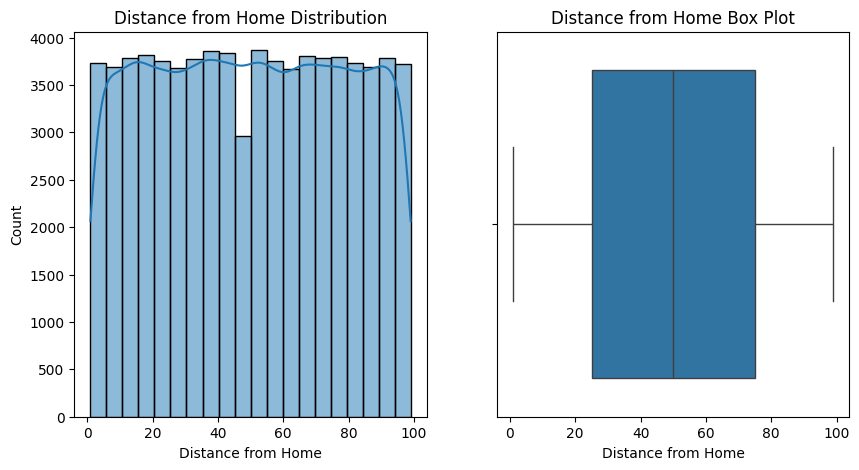

In [12]:
# Distance from Home

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Distance from Home'], kde=True, bins=20)
plt.title('Distance from Home Distribution')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Distance from Home'])
plt.title('Distance from Home Box Plot')
plt.show()

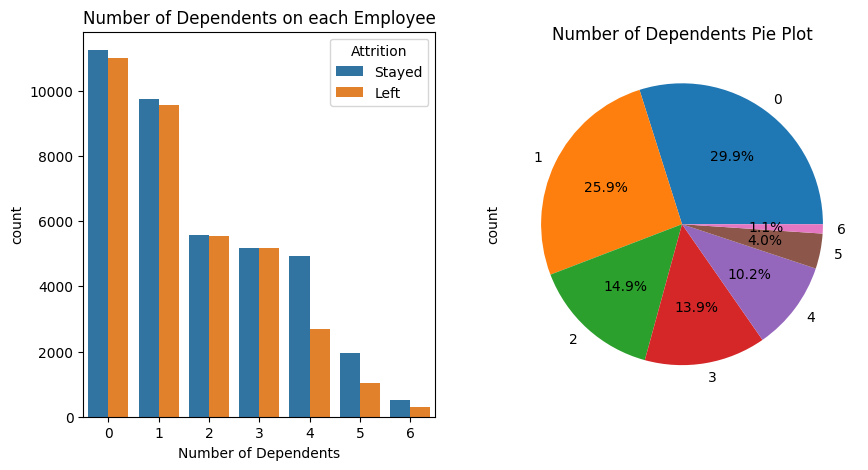

In [13]:
# Number of Dependents on each Employee

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x=df['Number of Dependents'], hue=df['Attrition'])
plt.title('Number of Dependents on each Employee')
plt.subplot(1,2,2)
df['Number of Dependents'].value_counts().plot.pie(autopct= '%1.1f%%')
plt.title('Number of Dependents Pie Plot')
plt.show()

In [14]:
# Explore Gender Column

df['Gender'].value_counts()

Gender
Male      40826
Female    33672
Name: count, dtype: int64

Gender             Female  Male
Months at Company              
1                    1354  1702
2                    1382  1657
3                    1330  1631
4                    1347  1556
5                    1377  1707
6                    1319  1633
7                    1351  1582
8                    1373  1642
9                    1323  1642
10                   1326  1661
11                   1345  1548
12                   1215  1543
13                   1145  1402
14                   1076  1273
15                   1046  1235
16                    947  1198
17                    883  1111
18                    854  1035
19                    781   973
20                    798   931
21                    724   882
22                    696   841
23                    724   833
24                    627   758
25                    577   696
26                    598   657
27                    514   693
28                    460   638
29                    499   558
30      

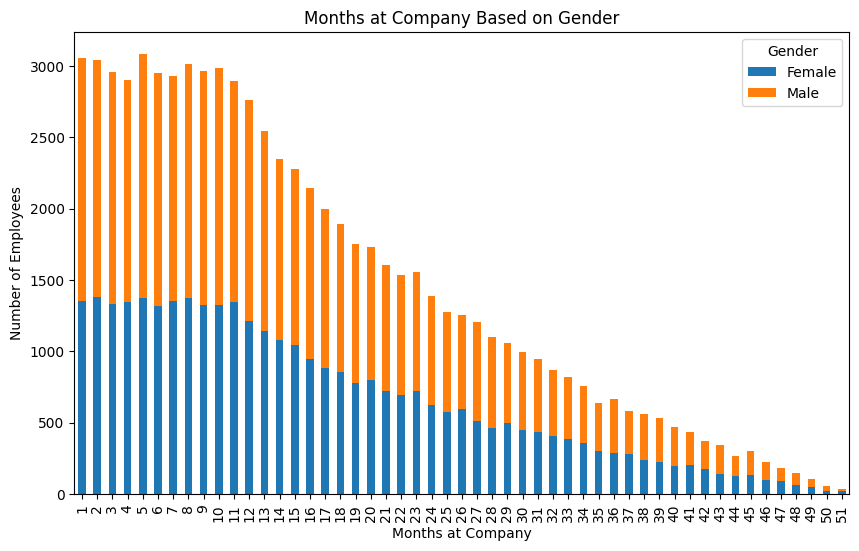

In [15]:
grouped = df.groupby(['Months at Company', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar',stacked=True, figsize=(10, 6))

plt.title('Months at Company Based on Gender')
plt.xlabel('Months at Company')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.show()

Job Roles Based on Gender

Gender      Female   Male
Job Role                 
Education     6950   8708
Finance       4696   5752
Healthcare    7696   9378
Media         5492   6504
Technology    8838  10484


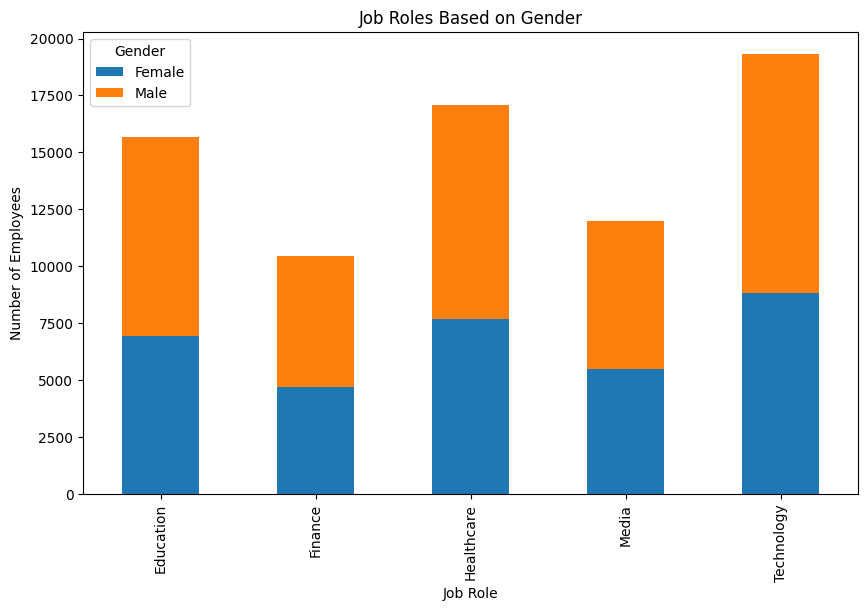

In [16]:
grouped = df.groupby(['Job Role', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar',stacked=True, figsize=(10, 6))
plt.title('Job Roles Based on Gender')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.show()

In [17]:
df['Gender'].value_counts()

Gender
Male      40826
Female    33672
Name: count, dtype: int64

Gender             Female   Male
Work-Life Balance               
Excellent            6053   7379
Fair                10172  12357
Good                12645  15513
Poor                 4802   5577


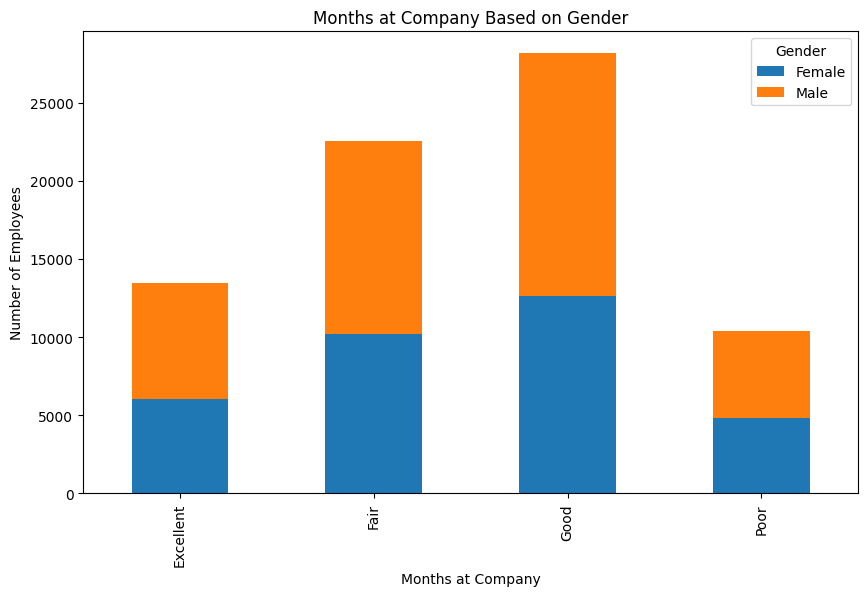

In [18]:
# Months at Company Based on Gender

grouped = df.groupby(['Work-Life Balance', 'Gender']).size().unstack(fill_value=0)

print(grouped)
grouped.plot(kind='bar',stacked=True, figsize=(10, 6))
plt.title('Months at Company Based on Gender')
plt.xlabel('Months at Company')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.show()

Job Satifaction Based on Gender

In [19]:
# Filter the DataFrame for rows where Gender is 'Female'
f= df[df['Gender'] == 'Female']

# Get the length of the filtered DataFrame
length_f = len(f)

# Filter the DataFrame for rows where Gender is 'Female'
m = df[df['Gender'] == 'Male']

# Get the length of the filtered DataFrame
length_m = len(m)

Gender               Female       Male
Job Satisfaction                      
High              50.086125  49.919169
Low                9.904372  10.096507
Medium            19.978023  19.570862
Very High         20.031480  20.413462


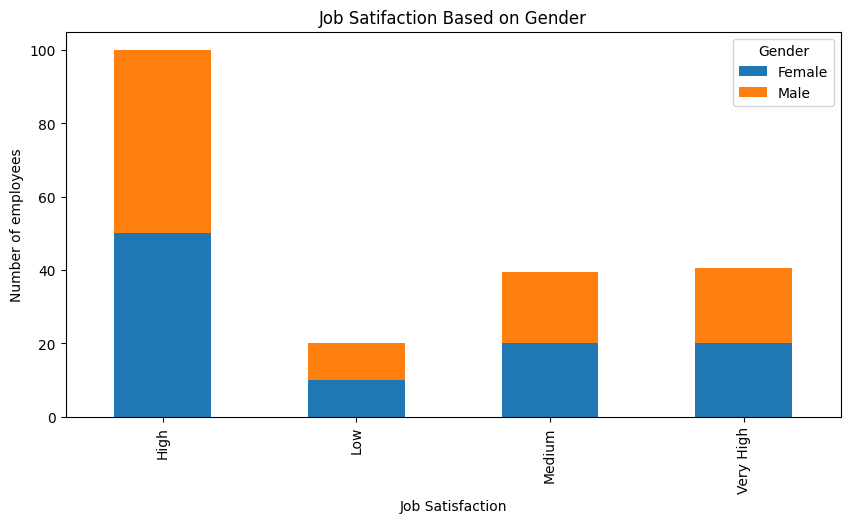

In [20]:
grouped = df.groupby(['Job Satisfaction', 'Gender']).size().unstack(fill_value=0)
grouped['Female'] = (grouped['Female']/length_f)*100
grouped['Male'] = (grouped['Male']/length_m)*100
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Job Satifaction Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Job Satisfaction')
plt.legend(title='Gender')

Gender              Female   Male
Performance Rating               
Average              20123  24596
Below Average         5043   6096
High                  6755   8155
Low                   1751   1979


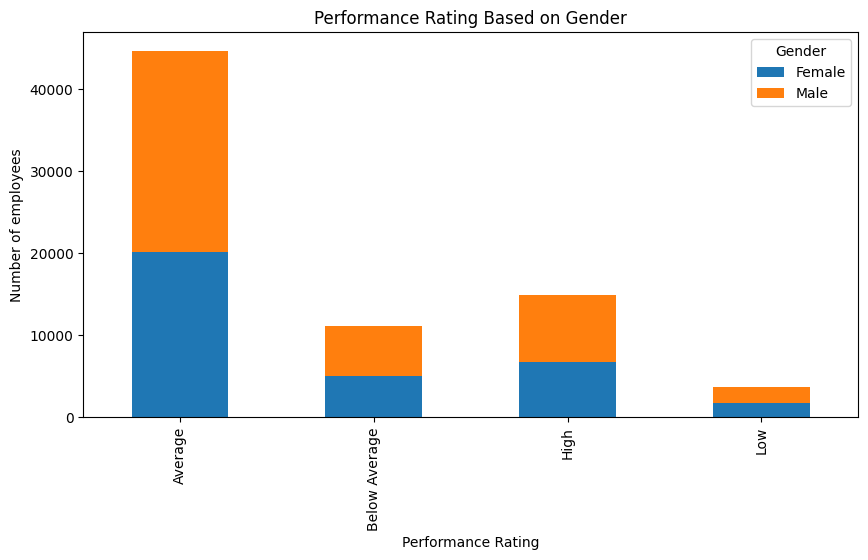

In [21]:
# Performance Rating Based on Gender

grouped = df.groupby(['Performance Rating', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Performance Rating Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Performance Rating')
plt.legend(title='Gender')

Gender              Female   Male
Performance Rating               
Average              20123  24596
Below Average         5043   6096
High                  6755   8155
Low                   1751   1979


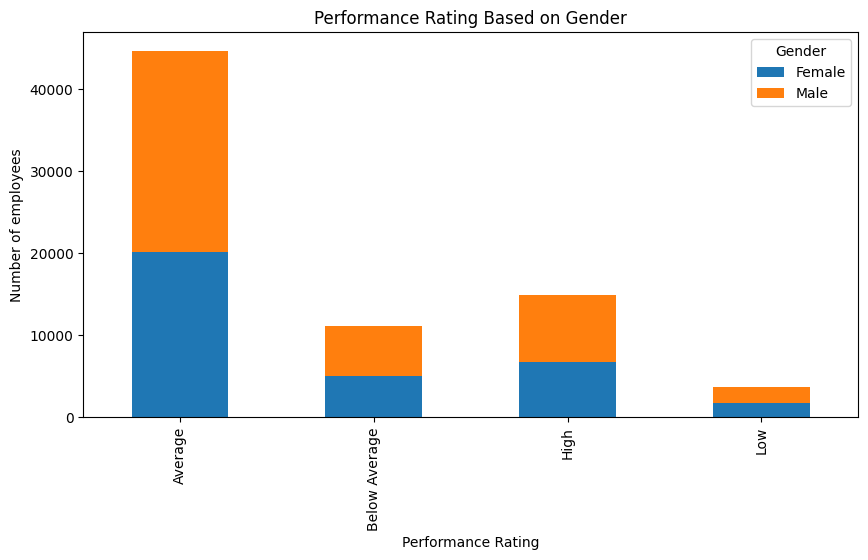

In [22]:
grouped = df.groupby(['Performance Rating', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Performance Rating Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Performance Rating')
plt.legend(title='Gender')

Number of Promotions Based on Gender
Gender                Female   Male
Number of Promotions               
0                      16751  20394
1                       8502  10179
2                       6095   7539
3                       1887   2162
4                        437    552
---------------------------


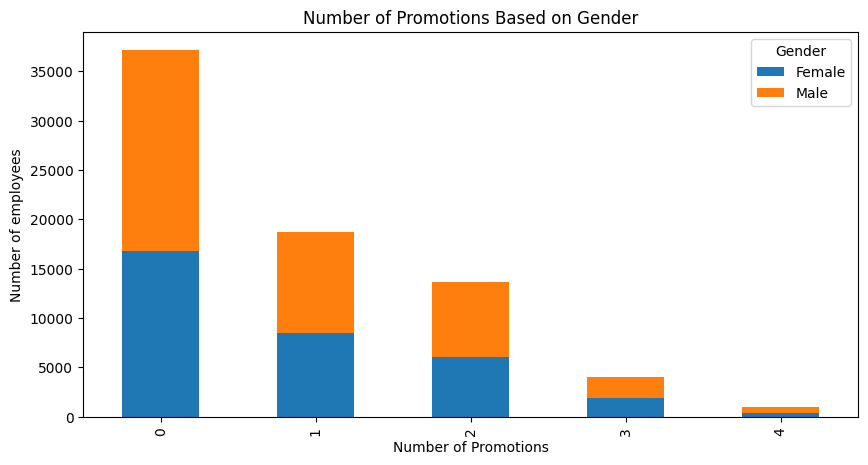

In [23]:
# Number of Promotions Based on Gender

grouped = df.groupby(['Number of Promotions', 'Gender']).size().unstack(fill_value=0)
print('Number of Promotions Based on Gender')
print(grouped)
print('---------------------------')
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Number of Promotions Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Number of Promotions')
plt.legend(title='Gender')

Gender    Female   Male
Overtime               
No         22670  27487
Yes        11002  13339


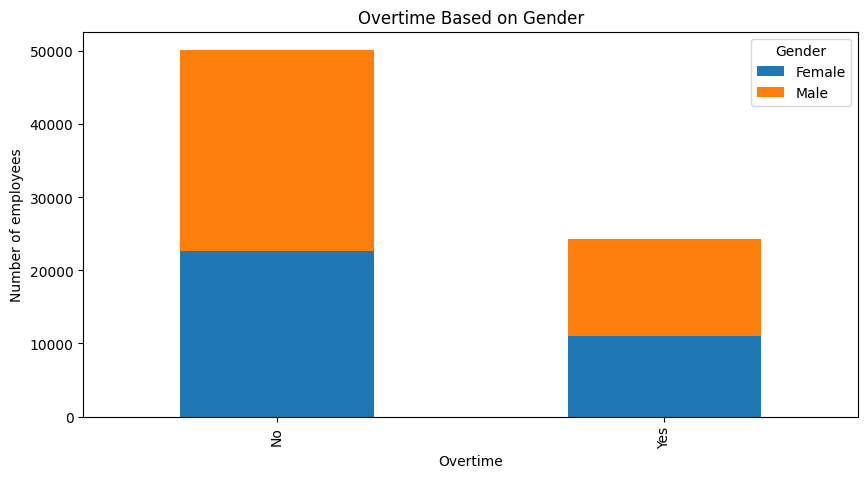

In [24]:
# Overtime Based on Gender

grouped = df.groupby(['Overtime', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Overtime Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Overtime')
plt.legend(title='Gender')

Gender             Female   Male
Education Level                 
Associate Degree     8451  10198
Bachelor’s Degree   10046  12285
High School          6608   8072
Master’s Degree      6758   8263
PhD                  1809   2008


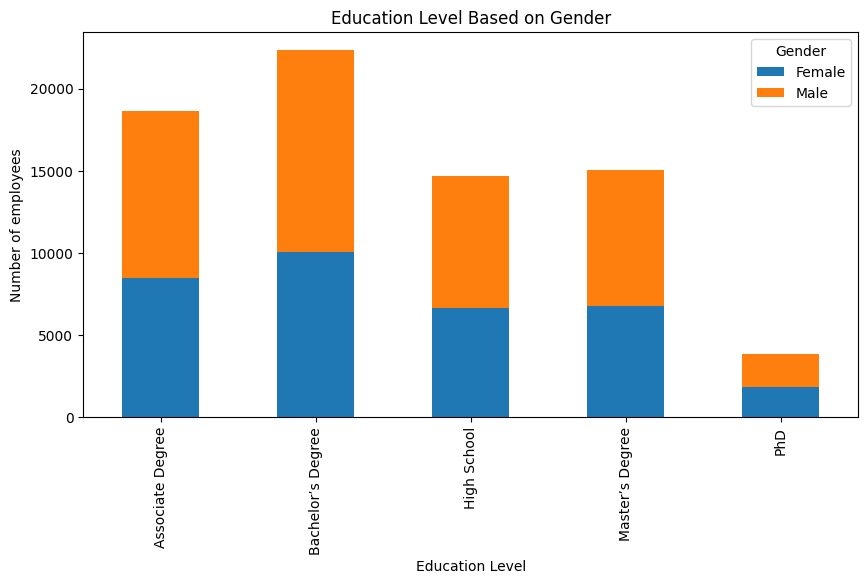

In [25]:
# Education Level Based on Gender

grouped = df.groupby(['Education Level', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Education Level Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Education Level')
plt.legend(title='Gender')

Gender     Female   Male
Job Level               
Entry       13476  16304
Mid         13476  16202
Senior       6720   8320


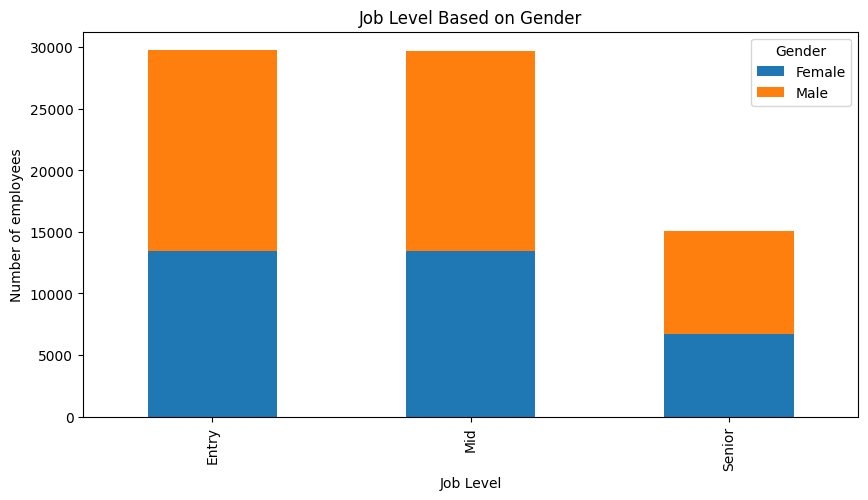

In [26]:
# Job Level Based on Gender

grouped = df.groupby(['Job Level', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Job Level Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Job Level')
plt.legend(title='Gender')

Gender        Female   Male
Company Size               
Large           6665   8247
Medium         16829  20402
Small          10178  12177


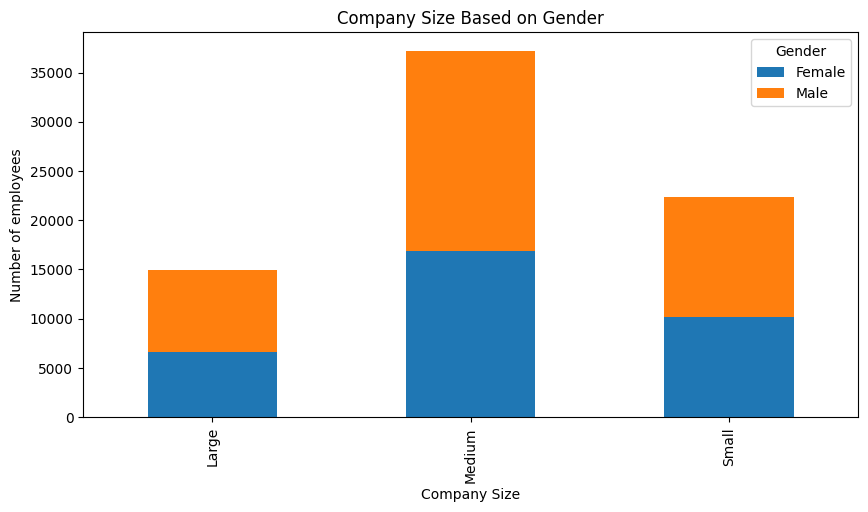

In [27]:
#Company Size Based on Gender

grouped = df.groupby(['Company Size', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Company Size Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Company Size')
plt.legend(title='Gender')

Gender       Female   Male
Remote Work               
No            27283  33017
Yes            6389   7809


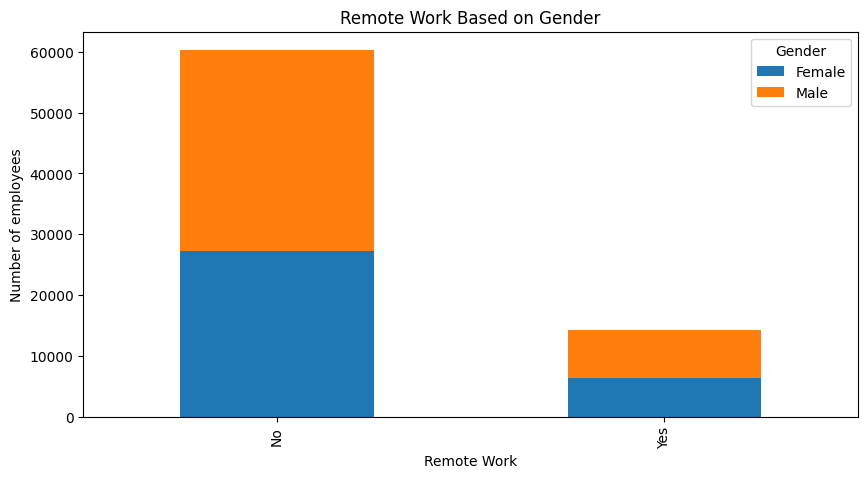

In [28]:
#Remote Work Based on Gender

grouped = df.groupby(['Remote Work', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Remote Work Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Remote Work')
plt.legend(title='Gender')

Gender                    Female   Male
Leadership Opportunities               
No                         32039  38806
Yes                         1633   2020


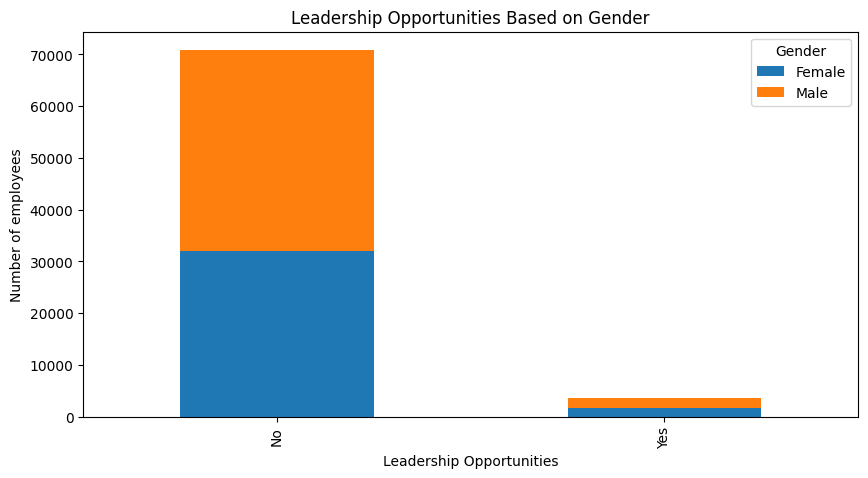

In [29]:
#Leadership Opportunities Based on Gender¶

grouped = df.groupby(['Leadership Opportunities', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Leadership Opportunities Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Leadership Opportunities')
plt.legend(title='Gender')

Gender                    Female   Male
Innovation Opportunities               
No                         28234  34160
Yes                         5438   6666


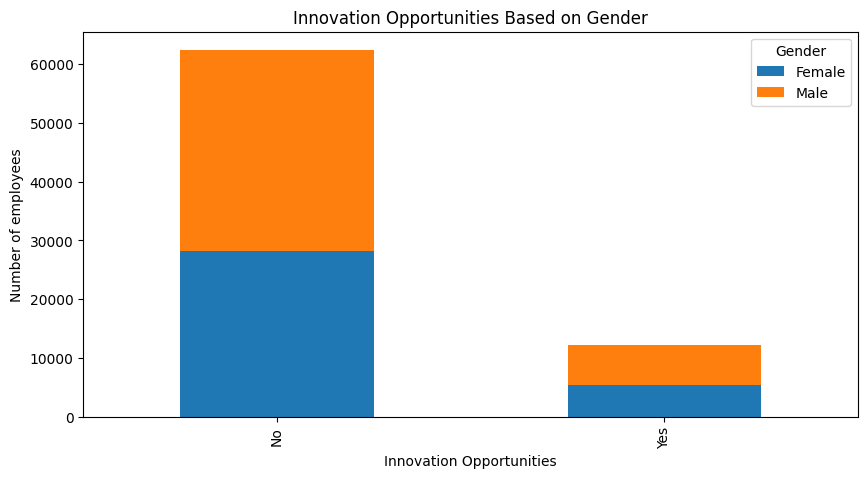

In [30]:
#Innovation Opportunities Based on Gender

grouped = df.groupby(['Innovation Opportunities', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Innovation Opportunities Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Innovation Opportunities')
plt.legend(title='Gender')

Gender              Female   Male
Company Reputation               
Excellent             3347   4067
Fair                  6654   8132
Good                 16913  20269
Poor                  6758   8358


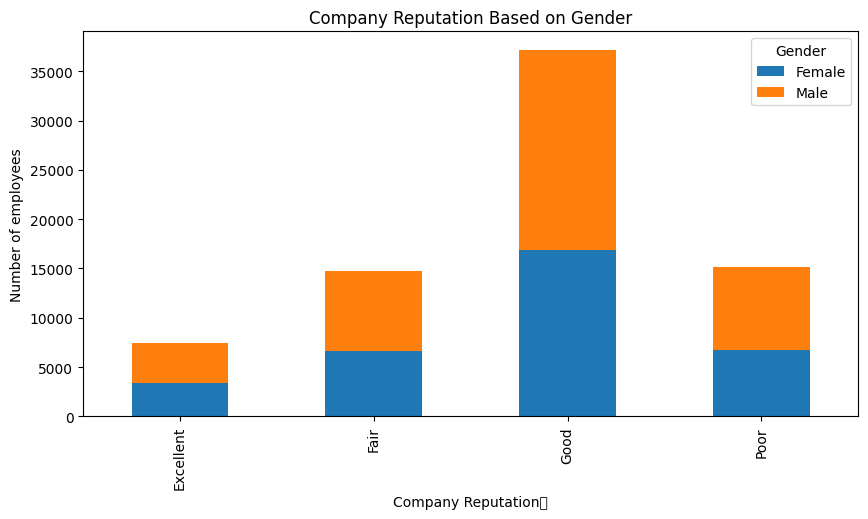

In [31]:
#Company Reputation Based on Gender

grouped = df.groupby(['Company Reputation', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Company Reputation Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Company Reputation	')
plt.legend(title='Gender')

Gender                Female   Male
Employee Recognition               
High                    8439  10111
Low                    13449  16171
Medium                 10114  12543
Very High               1670   2001


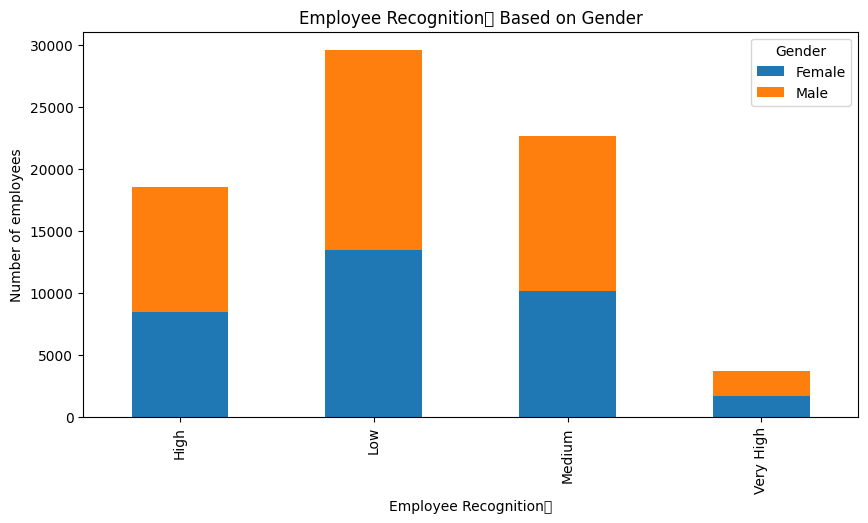

In [32]:
# Employee Recognition Based on Gender

grouped = df.groupby(['Employee Recognition', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Employee Recognition	 Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Employee Recognition	')
plt.legend(title='Gender')

Gender     Female   Male
Attrition               
Left        17850  17520
Stayed      15822  23306


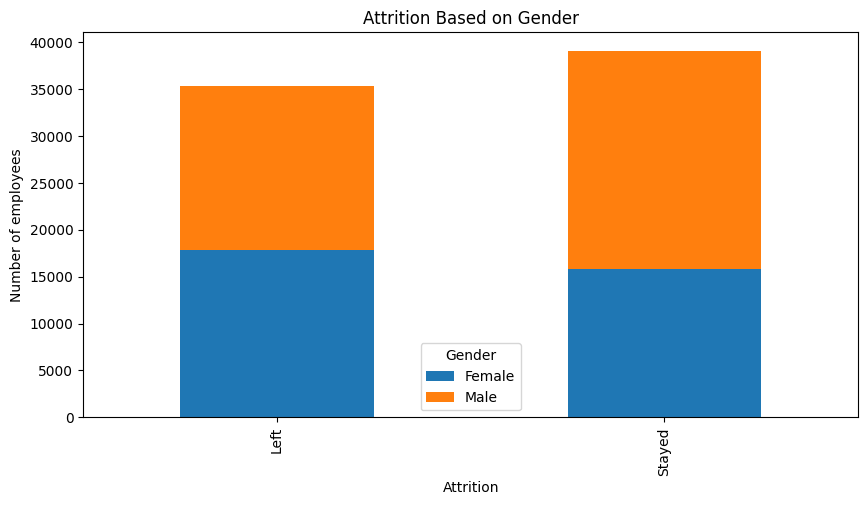

In [33]:
# Attrition Based on Gender

grouped = df.groupby(['Attrition', 'Gender']).size().unstack(fill_value=0)
print(grouped)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Attrition Based on Gender')
plt.ylabel('Number of employees')
plt.xlabel('Attrition')
plt.legend(title='Gender')

Attrition              Left  Stayed  Left_Percentage  Stayed_Percentage
Employee Recognition                                                   
High                   8734    9816        47.083558          52.916442
Low                   14163   15457        47.815665          52.184335
Medium                10784   11873        47.596769          52.403231
Very High              1689    1982        46.009262          53.990738


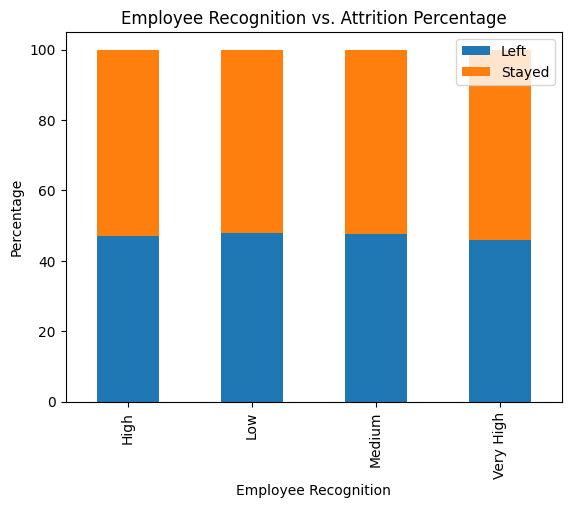

In [34]:
# Employee Recognition vs. Attrition Percentage

# Calculate the percentage of attrition within each recognition level
grouped = df.groupby(['Employee Recognition', 'Attrition']).size().unstack(fill_value=0)
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_Percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed'])) * 100

print(grouped)

# Plot the percentages
grouped[['Left_Percentage', 'Stayed_Percentage']].plot(kind='bar', stacked=True)
plt.title('Employee Recognition vs. Attrition Percentage')
plt.xlabel('Employee Recognition')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition            Left  Stayed  Left_Percentage  Stayed_percentage
Company Reputation                                                   
Excellent            3259    4155        43.957378          56.042622
Fair                 7655    7131        51.771946          48.228054
Good                15988   21194        42.999301          57.000699
Poor                 8468    6648        56.020111          43.979889


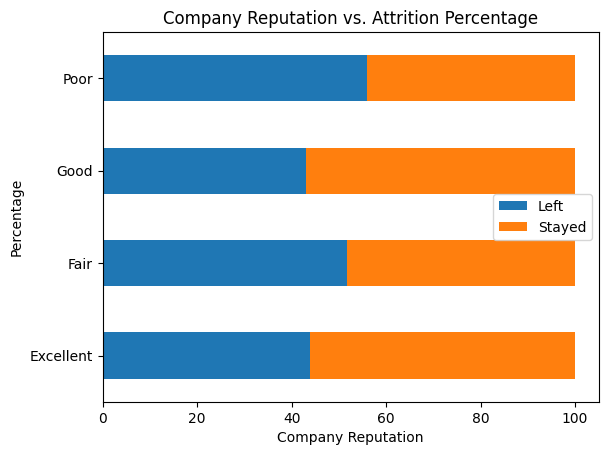

In [35]:
# Attrition vs Company Reputation

grouped = df.groupby(['Company Reputation', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='barh', stacked=True)
plt.title('Company Reputation vs. Attrition Percentage')
plt.xlabel('Company Reputation')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition     Left  Stayed  Left_Percentage  Stayed_percentage
Remote Work                                                   
No           31861   28439        52.837479          47.162521
Yes           3509   10689        24.714749          75.285251


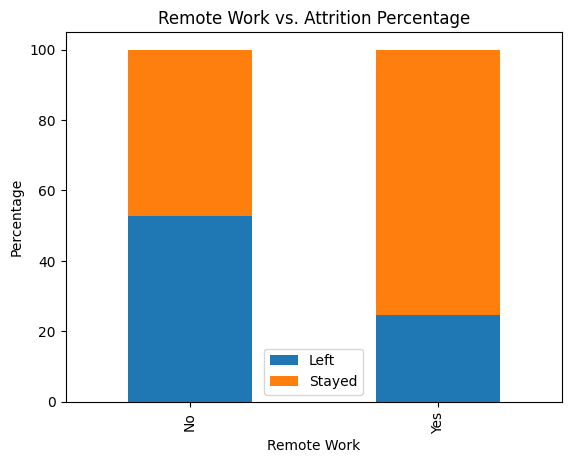

In [36]:
# Remote Work vs. Attrition Percentage

grouped = df.groupby(['Remote Work', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Remote Work vs. Attrition Percentage')
plt.xlabel('Remote Work')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition      Left  Stayed  Left_Percentage  Stayed_percentage
Company Size                                                   
Large          6942    7970        46.553112          53.446888
Medium        17324   19907        46.531117          53.468883
Small         11104   11251        49.671214          50.328786


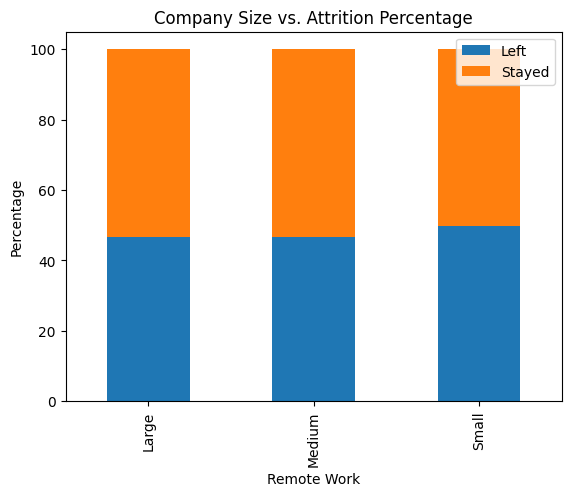

In [37]:
# Company Size vs. Attrition Percentage

grouped = df.groupby(['Company Size', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Company Size vs. Attrition Percentage')
plt.xlabel('Remote Work')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()


Attrition   Left  Stayed  Left_Percentage  Stayed_percentage
Job Level                                                   
Entry      18843   10937        63.274009          36.725991
Mid        13479   16199        45.417481          54.582519
Senior      3048   11992        20.265957          79.734043


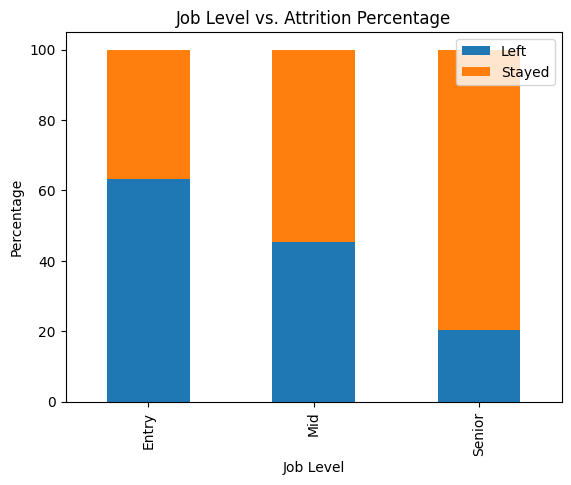

In [38]:
# Job Level vs. Attrition Percentage

grouped = df.groupby(['Job Level', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Job Level vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition              Left  Stayed  Left_Percentage  Stayed_percentage
Number of Dependents                                                   
0                     11009   11249        49.460868          50.539132
1                      9573    9758        49.521494          50.478506
2                      5554    5563        49.959521          50.040479
3                      5191    5184        50.033735          49.966265
4                      2702    4918        35.459318          64.540682
5                      1048    1958        34.863606          65.136394
6                       293     498        37.041719          62.958281


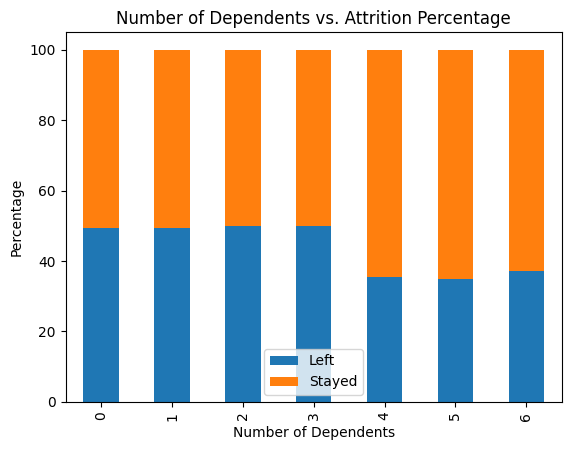

In [39]:
# Number of dependents vs Attrition Percentage

grouped = df.groupby(['Number of Dependents', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Number of Dependents vs. Attrition Percentage')
plt.xlabel('Number of Dependents')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition        Left  Stayed  Left_Percentage  Stayed_percentage
Marital Status                                                   
Divorced         4521    6557        40.810616          59.189384
Married         13485   23934        36.037842          63.962158
Single          17364    8637        66.782047          33.217953


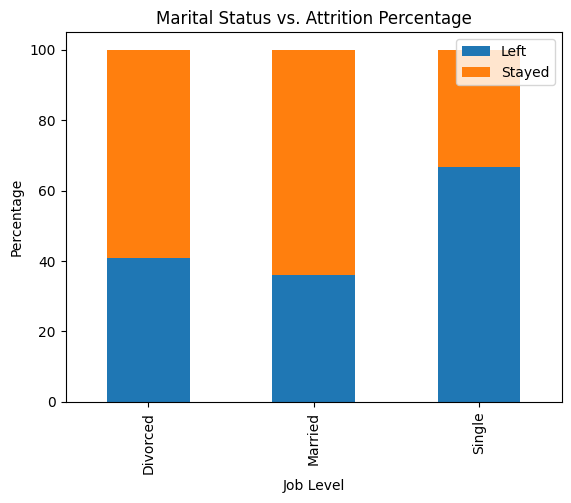

In [40]:
# Marital Status vs. Attrition Percentage

grouped = df.groupby(['Marital Status', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Marital Status vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition           Left  Stayed  Left_Percentage  Stayed_percentage
Education Level                                                     
Associate Degree    9077    9572        48.672851          51.327149
Bachelor’s Degree  10931   11400        48.949890          51.050110
High School         7098    7582        48.351499          51.648501
Master’s Degree     7332    7689        48.811664          51.188336
PhD                  932    2885        24.417081          75.582919


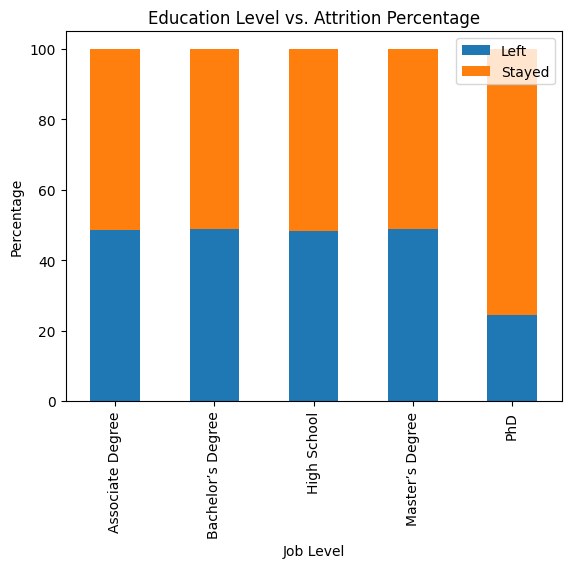

In [41]:
# Education Level vs. Attrition Percentage

grouped = df.groupby(['Education Level', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Education Level vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition           Left  Stayed  Left_Percentage  Stayed_percentage
Distance from Home                                                  
1                    302     435        40.976934          59.023066
2                    324     446        42.077922          57.922078
3                    318     400        44.289694          55.710306
4                    297     479        38.273196          61.726804
5                    325     401        44.765840          55.234160
...                  ...     ...              ...                ...
95                   388     350        52.574526          47.425474
96                   394     352        52.815013          47.184987
97                   377     379        49.867725          50.132275
98                   395     375        51.298701          48.701299
99                   376     334        52.957746          47.042254

[99 rows x 4 columns]


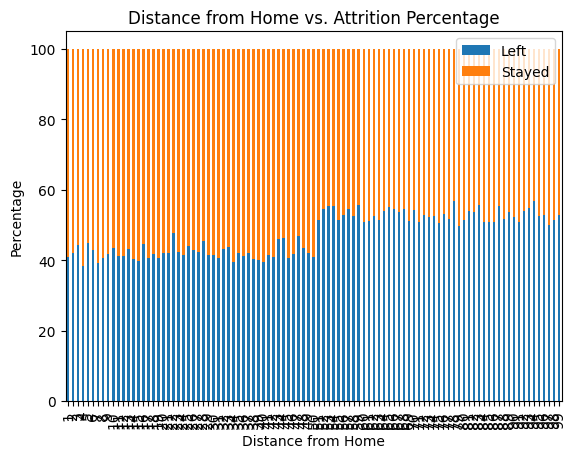

In [42]:
# Distance from Home vs Attrition Percentage

grouped = df.groupby(['Distance from Home', 'Attrition']).size().unstack(fill_value=0)

# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Distance from Home vs. Attrition Percentage')
plt.xlabel('Distance from Home')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition   Left  Stayed  Left_Percentage  Stayed_percentage
Overtime                                                    
No         22836   27321        45.529039          54.470961
Yes        12534   11807        51.493365          48.506635


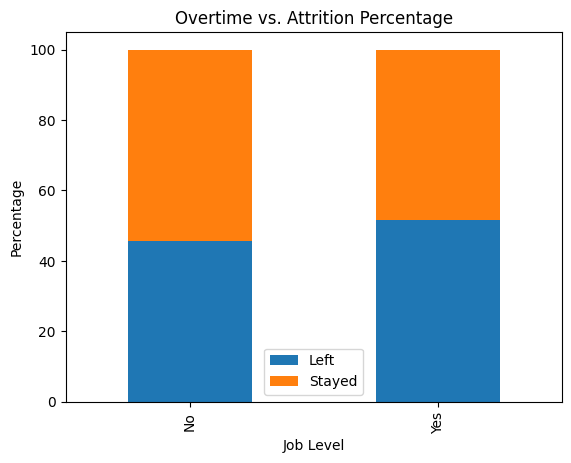

In [43]:
# Overtime vs. Attrition Percentage

grouped = df.groupby(['Overtime', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Overtime vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition              Left  Stayed  Left_Percentage  Stayed_percentage
Number of Promotions                                                   
0                     18304   18841        49.277157          50.722843
1                      9147    9534        48.964188          51.035812
2                      6679    6955        48.987825          51.012175
3                      1010    3039        24.944431          75.055569
4                       230     759        23.255814          76.744186


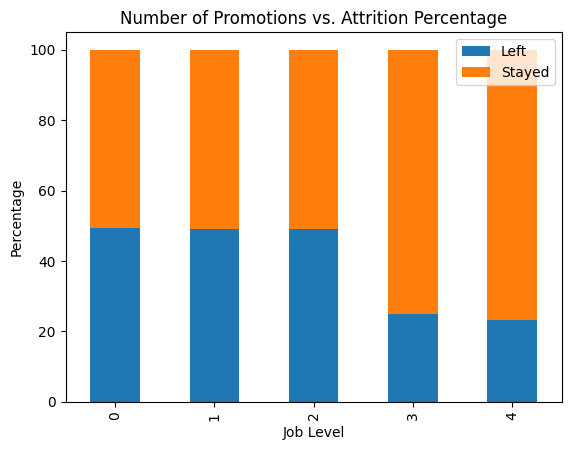

In [44]:
# Number of Promotions vs. Attrition Percentage

grouped = df.groupby(['Number of Promotions', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Number of Promotions vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition            Left  Stayed  Left_Percentage  Stayed_percentage
Performance Rating                                                   
Average             20607   24112        46.081084          53.918916
Below Average        5746    5393        51.584523          48.415477
High                 6889    8021        46.203890          53.796110
Low                  2128    1602        57.050938          42.949062


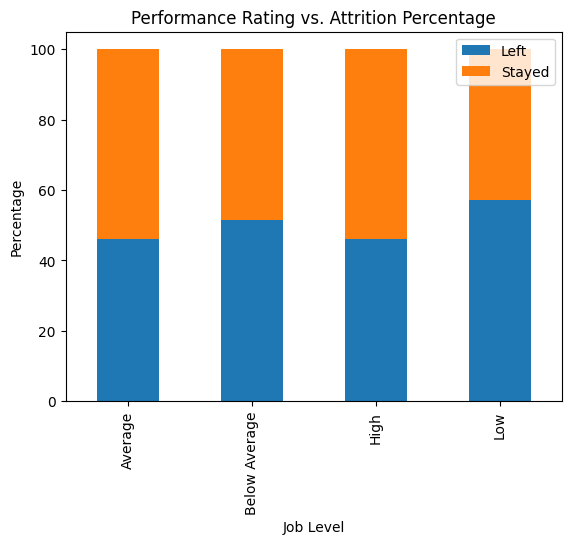

In [45]:
# Performance Rating vs. Attrition Percentage

grouped = df.groupby(['Performance Rating', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Performance Rating vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition          Left  Stayed  Left_Percentage  Stayed_percentage
Job Satisfaction                                                   
High              16759   20486        44.996644          55.003356
Low                3936    3521        52.782620          47.217380
Medium             6679    8038        45.382891          54.617109
Very High          7996    7083        53.027389          46.972611


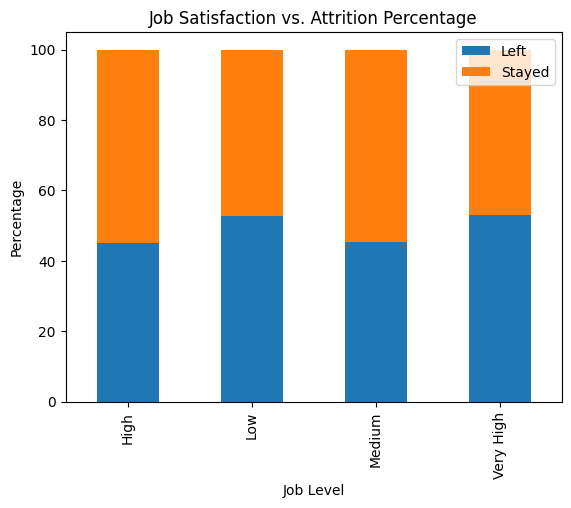

In [46]:
# Job Satisfaction vs. Attrition Percentage

grouped = df.groupby(['Job Satisfaction', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Job Satisfaction vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition           Left  Stayed  Left_Percentage  Stayed_percentage
Work-Life Balance                                                   
Excellent           4789    8643        35.653663          64.346337
Fair               12967    9562        57.556927          42.443073
Good               11368   16790        40.372186          59.627814
Poor                6246    4133        60.179208          39.820792


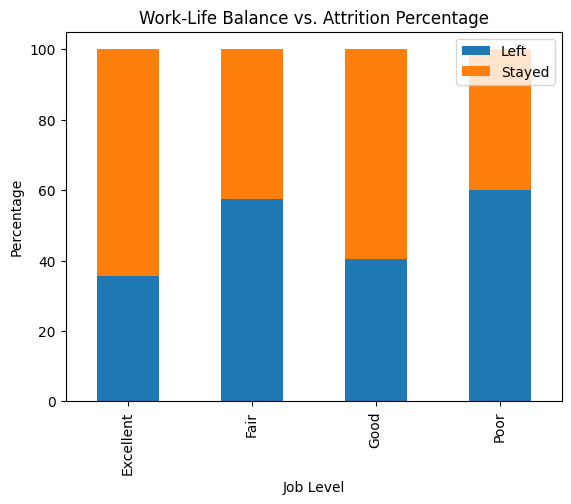

In [47]:
# Work-Life Balance vs Attrition Percentage

grouped = df.groupby(['Work-Life Balance', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Work-Life Balance vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

In [48]:
# Monthly Income vs Attrition Rate

df['income_categories'] = pd.cut(df['Monthly Income'], bins=[1000, 5000, 10000, float(np.inf)],
                                 labels=['1k-5k', '5k-10k', '10k+'])
df['income_categories'].value_counts()

income_categories
5k-10k    54109
1k-5k     12267
10k+       8122
Name: count, dtype: int64

Attrition           Left  Stayed  Left_Percentage  Stayed_percentage
income_categories                                                   
1k-5k               6040    6227        49.237792          50.762208
5k-10k             25500   28609        47.127095          52.872905
10k+                3830    4292        47.155873          52.844127


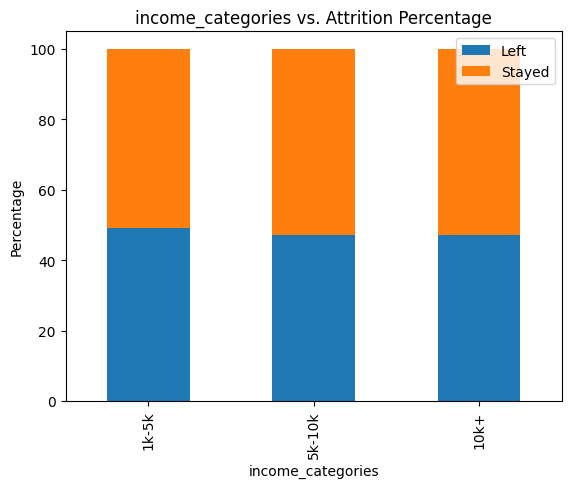

In [49]:
grouped = df.groupby(['income_categories', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('income_categories vs. Attrition Percentage')
plt.xlabel('income_categories')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition   Left  Stayed  Left_Percentage  Stayed_percentage
Job Role                                                    
Education   7636    8022        48.767403          51.232597
Finance     4903    5545        46.927642          53.072358
Healthcare  8112    8962        47.510835          52.489165
Media       5620    6376        46.848950          53.151050
Technology  9099   10223        47.091398          52.908602


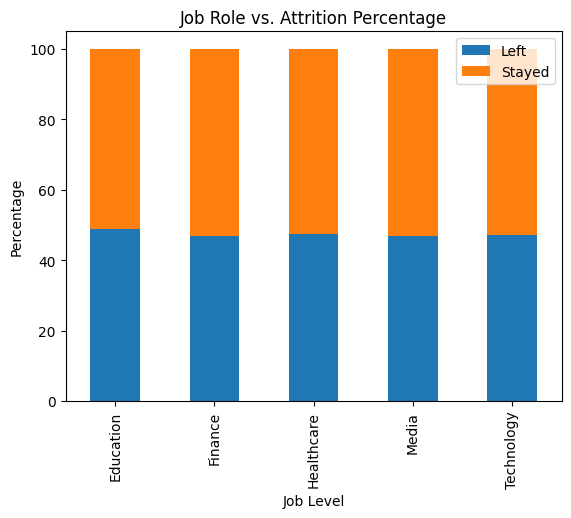

In [50]:
# Job Role vs Attrition Percentage

grouped = df.groupby(['Job Role', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)


grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Job Role vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

In [51]:
# Months at Company vs Attrition Percentage

df['Months at Company(Categories)'] = pd.cut(df['Months at Company'], bins=[1,5,10,20,30,40,51],
                                            labels=['1-5', '5-10','10-20','20-30', '30-40','40-51'])

Attrition                      Left  Stayed  Left_Percentage  \
Months at Company(Categories)                                  
1-5                            6380    5607        53.224326   
5-10                           7667    7185        51.622677   
10-20                          9988   12351        44.711043   
20-30                          5609    7364        43.235952   
30-40                          3048    3791        44.567919   
40-51                          1082    1370        44.127243   

Attrition                      Stayed_Percentage  
Months at Company(Categories)                     
1-5                                    46.775674  
5-10                                   48.377323  
10-20                                  55.288957  
20-30                                  56.764048  
30-40                                  55.432081  
40-51                                  55.872757  


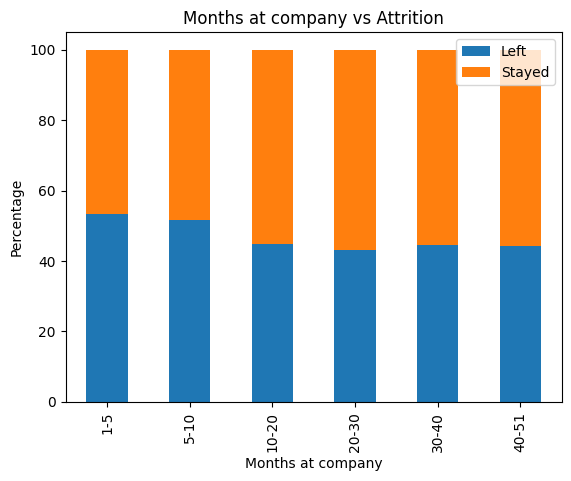

In [52]:
grouped = df.groupby(['Months at Company(Categories)', 'Attrition']).size().unstack(fill_value=0)
grouped['Left_Percentage'] = (grouped['Left'])/(grouped['Left']+grouped['Stayed'])*100
grouped['Stayed_Percentage'] = (grouped['Stayed'])/(grouped['Left']+grouped['Stayed'])*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_Percentage']].plot(kind='bar', stacked=True)
plt.title('Months at company vs Attrition')
plt.xlabel('Months at company')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition   Left  Stayed  Left_Percentage  Stayed_percentage
Gender                                                      
Female     17850   15822        53.011404          46.988596
Male       17520   23306        42.913829          57.086171


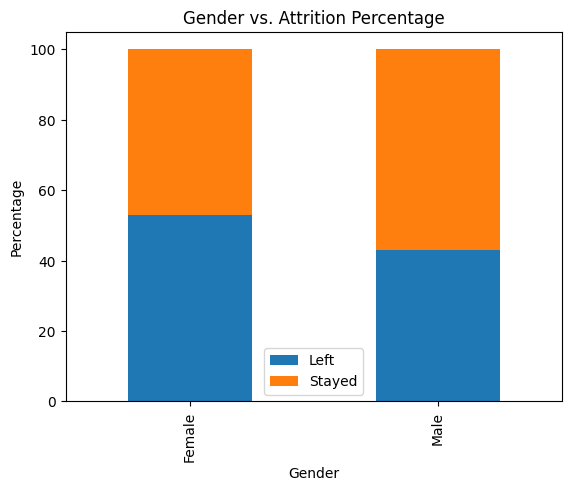

In [53]:
# Gender vs. Attrition Percentage

grouped = df.groupby(['Gender', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Gender vs. Attrition Percentage')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

Attrition        Left  Stayed  Left_Percentage  Stayed_Percentage
Age_categories                                                   
18-30           10877   10251        51.481446          48.518554
30-50           16369   19384        45.783571          54.216429
50+              7197    8718        45.221489          54.778511


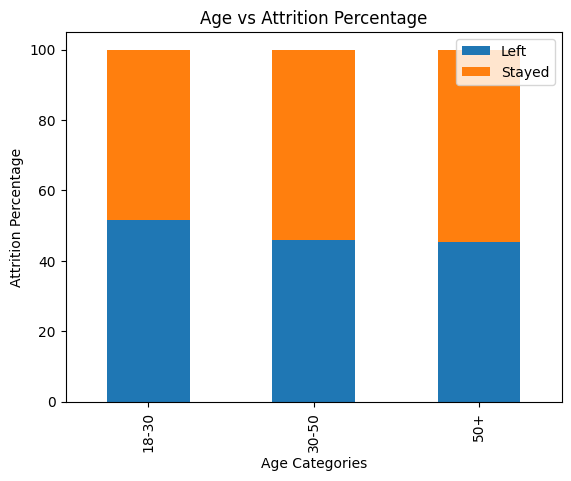

In [54]:
# Age vs Attrition Percentage

df['Age_categories'] = pd.cut(df['Age'], bins=[18, 30, 50, float('inf')], labels=['18-30', '30-50', '50+'])
grouped = df.groupby(['Age_categories', 'Attrition']).size().unstack(fill_value=0)
grouped['Left_Percentage'] = (grouped['Left'])/(grouped['Left']+grouped['Stayed'])*100

grouped['Stayed_Percentage'] = (grouped['Stayed'])/(grouped['Left']+grouped['Stayed'])*100
grouped[['Left_Percentage', 'Stayed_Percentage']].plot(kind='bar', stacked=True)
print(grouped)
plt.xlabel('Age Categories')
plt.ylabel('Attrition Percentage')
plt.title('Age vs Attrition Percentage')
plt.legend(['Left','Stayed'])

Attrition           Left  Stayed  Left_Percentage  Stayed_percentage
Education Level                                                     
Associate Degree    9077    9572        48.672851          51.327149
Bachelor’s Degree  10931   11400        48.949890          51.050110
High School         7098    7582        48.351499          51.648501
Master’s Degree     7332    7689        48.811664          51.188336
PhD                  932    2885        24.417081          75.582919


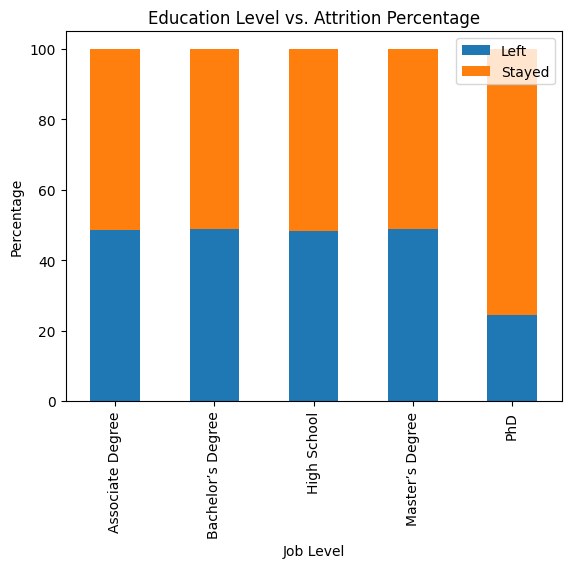

In [55]:
# Education Level vs. Attrition Percentage

grouped = df.groupby(['Education Level', 'Attrition']).size().unstack(fill_value=0)
# percentage
grouped['Left_Percentage'] = (grouped['Left'] / (grouped['Left'] + grouped['Stayed'])) * 100
grouped['Stayed_percentage'] = (grouped['Stayed'] / (grouped['Left'] + grouped['Stayed']))*100
print(grouped)
grouped[['Left_Percentage', 'Stayed_percentage']].plot(kind='bar', stacked=True)
plt.title('Education Level vs. Attrition Percentage')
plt.xlabel('Job Level')
plt.ylabel('Percentage')
plt.legend(['Left', 'Stayed'])
plt.show()

***** Remark *****

- Phân tích chéo cho thấy rủi ro nghỉ việc tập trung mạnh ở nhóm nhân sự trẻ tuổi độc thân (Marital Status = Single chiếm 66.78%) và cấp bậc mới vào nghề (Job Level = Entry chiếm 63.2%)
- Bên cạnh đó, các yếu tố môi trường như làm thêm giờ (Overtime = Yes), không được làm từ xa (Remote Work = No chiếm 52.95%), và khoảng cách đi làm xa trên 50km là những nguyên nhân trực tiếp thúc đẩy tỷ lệ rời bỏ tổ chức nhảy vọt

# 3. DATA PREPROCESSING & PREPARE FOR BIGQUERY

In [56]:
# 3.1. Define temporary columns created during EDA that need to be removed
cols_to_drop = [
    'Employee ID', 'Distance from Home_Categories', 'income_categories', 
    'Years at Company(Categories)', 'Age_categories', 'Months at Company(Categories)'
]
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3.2. Encode the target variable 'Attrition' as numeric (Stayed -> 0, Left -> 1)
df_clean['Attrition'] = df_clean['Attrition'].map({'Stayed': 0, 'Left': 1})

# 3.3. Rename all columns containing spaces or special characters to avoid BigQuery errors
rename_dict = {
    'Months at Company': 'MonthsInCompany',
    'Job Role': 'JobRole',
    'Monthly Income': 'MonthlyIncome',
    'Work-Life Balance': 'WorkLifeBalance',
    'Job Satisfaction': 'JobSatisfaction',
    'Performance Rating': 'PerformanceRating',
    'Number of Promotions': 'NumberOfPromotions',
    'Distance from Home': 'DistanceFromHome',
    'Education Level': 'EducationLevel',
    'Marital Status': 'MaritalStatus',
    'Number of Dependents': 'NumberOfDependents',
    'Job Level': 'JobLevel',
    'Company Size': 'CompanySize',
    'Remote Work': 'RemoteWork',
    'Leadership Opportunities': 'LeadershipOpportunities',
    'Innovation Opportunities': 'InnovationOpportunities',
    'Company Reputation': 'CompanyReputation',
    'Employee Recognition': 'EmployeeRecognition'
}
df_clean = df_clean.rename(columns=rename_dict)

# 3.4. Split the cleaned dataset back into the original training and testing sets based on the length of the original train_df
len_train = len(train_df)

train_cleaned = df_clean.iloc[:len_train].reset_index(drop=True)
test_cleaned = df_clean.iloc[len_train:].reset_index(drop=True)

# 3.5. Export file for BigQuery
train_cleaned.to_csv('train_cleaned.csv', index=False)
test_cleaned.to_csv('test_cleaned.csv', index=False)

print("Tiền xử lý hoàn tất!")
print(f"-> Kích thước tập Train sạch xuất ra: {train_cleaned.shape}")
print(f"-> Kích thước tập Test sạch xuất ra: {test_cleaned.shape}")
print("-> Đã lưu thành công hai file 'train_cleaned.csv' và 'test_cleaned.csv' tại thư mục làm việc!")

Tiền xử lý hoàn tất!
-> Kích thước tập Train sạch xuất ra: (59598, 22)
-> Kích thước tập Test sạch xuất ra: (14900, 22)
-> Đã lưu thành công hai file 'train_cleaned.csv' và 'test_cleaned.csv' tại thư mục làm việc!


# 4. VISUALIZATION & MODEL COMPARISON

In [66]:
# 4.1. Loading data from BigQuery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

pred_df = pd.read_csv('bigquery_predictions_1.csv')

print("Cấu trúc file dữ liệu dự đoán từ BigQuery:", pred_df.shape)
print("\nHiển thị 5 dòng dữ liệu đầu tiên:")
display(pred_df.head())

Cấu trúc file dữ liệu dự đoán từ BigQuery: (14900, 8)

Hiển thị 5 dòng dữ liệu đầu tiên:


,Age,Gender,MonthlyIncome,JobRole,actual_status,predicted_Attrition,prob_stayed,prob_left
0,18,Male,7571,Healthcare,0,0,0.082647,0.917353
1,18,Male,9228,Technology,1,0,0.247567,0.752433
2,18,Female,10359,Finance,0,0,0.307786,0.692214
3,18,Male,7916,Healthcare,1,0,0.356392,0.643608
4,18,Male,3522,Education,1,0,0.484342,0.515658


In [67]:
# 4.2. Classification report

print("LOGISTIC REGRESSION MODEL PERFORMANCE REPORT")
print(classification_report(pred_df['actual_status'], pred_df['predicted_Attrition'], 
                            target_names=['Stayed', 'Left']))

LOGISTIC REGRESSION MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

      Stayed       0.79      0.73      0.76      7792
        Left       0.72      0.78      0.75      7108

    accuracy                           0.75     14900
   macro avg       0.75      0.76      0.75     14900
weighted avg       0.76      0.75      0.75     14900



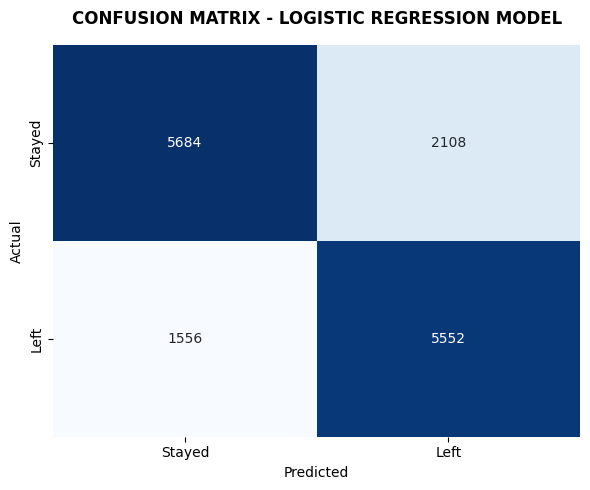

In [68]:
# 4.3. Confusion Matrix

cm = confusion_matrix(pred_df['actual_status'], pred_df['predicted_Attrition'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed', 'Left'], 
            yticklabels=['Stayed', 'Left'])

plt.title('CONFUSION MATRIX - LOGISTIC REGRESSION MODEL', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=10)
plt.xlabel('Predicted', fontsize=10)
plt.tight_layout()
plt.show()

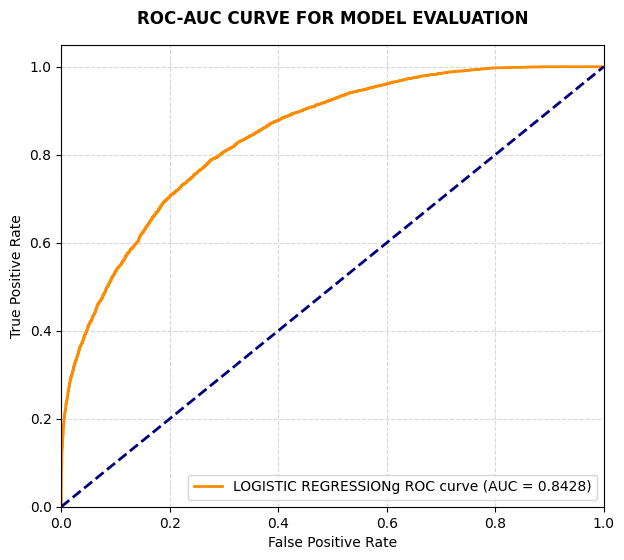

In [69]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = pred_df['actual_status'].astype(int)

# Nếu prob_left đang bị ngược, đảo lại
y_score = 1 - pred_df['prob_left']

fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LOGISTIC REGRESSIONg ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.title('ROC-AUC CURVE FOR MODEL EVALUATION', fontsize=12, fontweight='bold', pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

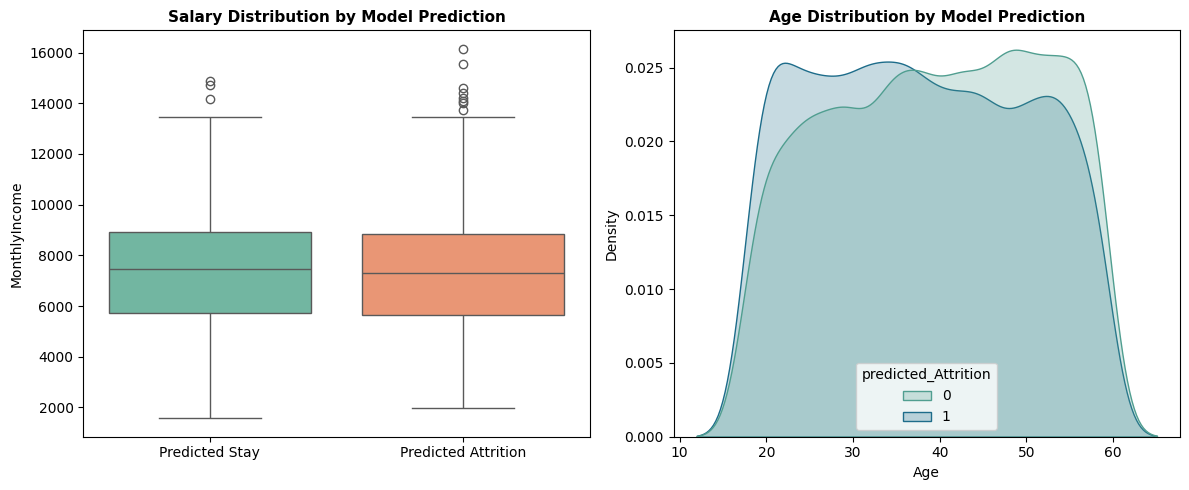

In [61]:
# 4.5. Deep-dive Analysis
# Use the demographic features (e.g., Age, MonthlyIncome) selected from BigQuery
# To visualize the risk distribution and provide actionable insights for management

plt.figure(figsize=(12, 5))

# Chart: Salary Distribution by Model Prediction
plt.subplot(1, 2, 1)
sns.boxplot(x='predicted_Attrition', y='MonthlyIncome', data=pred_df, palette='Set2')
plt.xticks([0, 1], ['Predicted Stay', 'Predicted Attrition'])
plt.title('Salary Distribution by Model Prediction', fontsize=11, fontweight='bold')
plt.xlabel('')

# Chart: Age Distribution by Model Prediction
plt.subplot(1, 2, 2)
sns.kdeplot(data=pred_df, x='Age', hue='predicted_Attrition', fill=True, common_norm=False, palette='crest')
plt.title('Age Distribution by Model Prediction', fontsize=11, fontweight='bold')
plt.xlabel('Age')

plt.tight_layout()
plt.show()

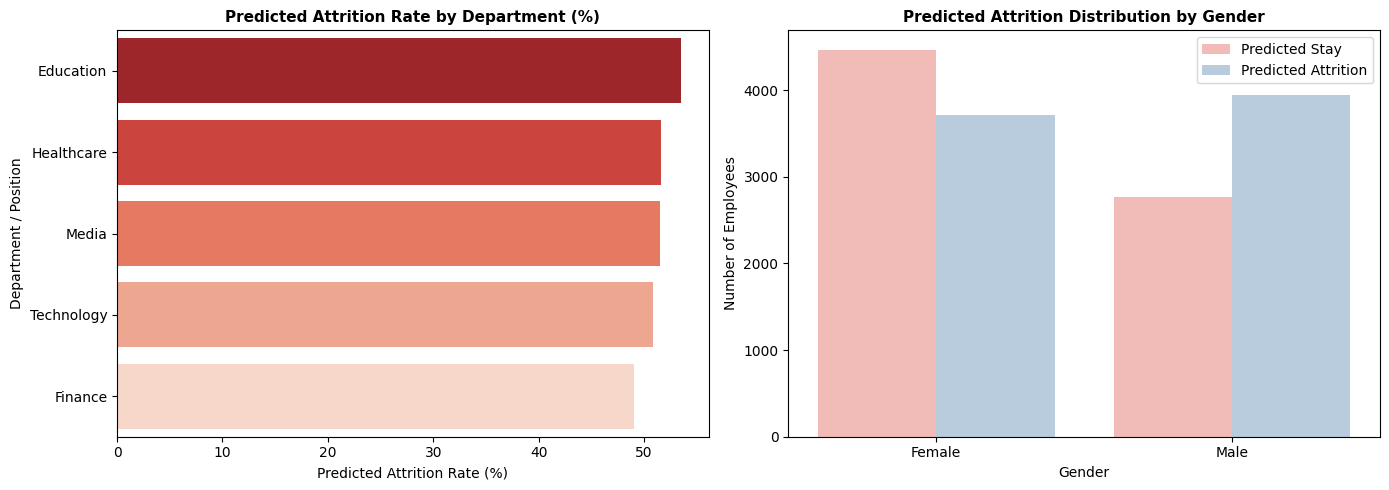

In [62]:
# 4.6. Cross - Analysis

plt.figure(figsize=(14, 5))

# Chart 1: Job Role vs. Predicted Attrition Rate
plt.subplot(1, 2, 1)
role_attrition = pred_df.groupby('JobRole')['predicted_Attrition'].mean().sort_values(ascending=False) * 100
sns.barplot(x=role_attrition.values, y=role_attrition.index, palette='Reds_r')
plt.title('Predicted Attrition Rate by Department (%)', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Attrition Rate (%)')
plt.ylabel('Department / Position')

# Chart 2: Predicted Attrition Distribution by Gender

plt.subplot(1, 2, 2)
sns.countplot(data=pred_df, x='Gender', hue='predicted_Attrition', palette='Pastel1')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(['Predicted Stay', 'Predicted Attrition'])
plt.title('Predicted Attrition Distribution by Gender', fontsize=11, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()

In [63]:
# 4.6. Model Evaluation Summary

📌 Kết luận hiệu năng mô hình:
- Mô hình  chạy trên BigQuery đạt chỉ số AUC-ROC xuất sắc (khoảng 0.83). Điều này chứng minh mô hình có khả năng phân biệt cực kỳ mạnh mẽ giữa người có xu hướng nghỉ việc và người muốn gắn bó

- Dựa trên Confusion Matrix, tỷ lệ mô hình đoán đúng các ca thực tế nghỉ việc đạt mức cao, giúp phòng HR giảm thiểu tối đa việc bỏ sót các nhân tài sắp rời đi

# 5. BUSINESS INSIGHT 

Dựa trên kết quả dự đoán từ mô hình Logistic Regression (với độ chính xác AUC-ROC đạt mức tối ưu ~0.84), bộ phận Phân tích Nhân sự (HR Analyst) rút ra các insight cốt lõi sau về tình trạng rời bỏ tổ chức:

- "Điểm nóng" rủi ro - Nhóm nhân sự độc thân (Single) và Cấp bậc thấp (Entry Level):

>> Mô hình đồng nhất với kết quả EDA khi gắn cờ nguy cơ cao tập trung vào nhóm nhân viên Single (Tỷ lệ nghỉ thực tế trước đó là 66.78%) và nhóm Entry Level (63.2%). Đây là nhóm nhân sự trẻ, có mức độ ràng buộc với tổ chức thấp và dễ bị dao động bởi các cơ hội bên ngoài

- Khủng hoảng khoảng cách địa lý (Distance From Home):

>> Mô hình phân loại đánh giá biến DistanceFromHome nằm trong top những đặc trưng quan trọng nhất. Áp lực di chuyển trên quãng đường dài (đặc biệt vượt ngưỡng 50km làm tỷ lệ nghỉ việc tăng vọt lên 52.95%) là nguyên nhân trực tiếp bào mòn thể lực và sự gắn kết của nhân sự

- Mối liên hệ giữa Thu nhập và Chế độ làm việc linh hoạt:

>> Nhóm nhân viên bị mô hình dự đoán nghỉ việc (predicted_Attrition = 1) có dải lương (MonthlyIncome) trung vị thấp hơn rõ rệt so với nhóm ở lại. Đặc biệt, những nhân sự không được làm việc từ xa (Remote Work = No) có tỷ lệ rời đi cao gấp đôi nhóm được làm việc linh hoạt

# 6. RECOMMMENDATIONS

Để giải quyết bài toán cốt lõi: "Giữ chân nhân tài có hiệu suất tốt, tối ưu chi phí tuyển dụng" theo yêu cầu của Ban giám đốc, phòng HR đề xuất 3 giải pháp hành động dựa trên dữ liệu:

1. Triển khai Hệ thống Cảnh báo sớm (Early Warning System) dựa vào Machine Learning
   
>> Phòng HR sẽ tích hợp mô hình Logistic Regression vào hệ thống quản trị nhân sự (HRMS) để thực hiện quét dữ liệu định kỳ vào cuối mỗi quý

>> Những nhân viên xuất sắc có hiệu suất tốt (Performance Rating cao) nhưng bị mô hình gắn cờ dự đoán predicted_Attrition = 1 với mức xác suất nghỉ việc (prob_left) trên 70% sẽ lập tức được đưa vào danh sách "Chăm sóc đặc biệt"

2. Can thiệp chủ động thông qua Phỏng vấn giữ chân (Stay Interview)

>> Đối với danh sách nhân sự bị cảnh báo rủi ro, HR sẽ phối hợp với Line Manager để tổ chức các buổi Stay Interview

>> Nội dung tập trung vào lắng nghe tâm tư nguyện vọng, làm rõ lộ trình thăng tiến (giải quyết bài toán kẹt ở Entry Level quá lâu) và ghi nhận đóng góp kịp thời (Employee Recognition)

3. Tối ưu chính sách phúc lợi điều chỉnh theo "Nỗi đau" (Painpoints) của nhân sự
   
>> Giải pháp địa lý: Áp dụng mô hình làm việc linh hoạt Hybrid Work (Ví dụ: cho phép làm Remote 2 ngày/tuần) đối với nhóm nhân sự có khoảng cách nhà xa trên 50km để giảm áp lực di chuyển. Dữ liệu chứng minh giải pháp này có thể kéo giảm tỷ lệ nguy cơ nghỉ việc từ 52.9% xuống dưới 25%

>> Giải pháp tài chính: Rà soát lại base lương của các vị trí có tỷ lệ dự đoán nghỉ việc cao đột biến để thực hiện điều chỉnh thu nhập hoặc tăng phụ cấp thâm niên, đảm bảo tính cạnh tranh với thị trường